In [2]:
!pip install scikit-learn pandas matplotlib seaborn

Saving Coursera.csv to Coursera.csv
Dataset Shape: (3522, 7)

Columns:
['Course Name', 'University', 'Difficulty Level', 'Course Rating', 'Course URL', 'Course Description', 'Skills']

First 5 Rows:


,Course Name,University,Difficulty Level,Course Rating,Course URL,Course Description,Skills
0,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,Write a Full Length Feature Film Script In th...,Drama Comedy peering screenwriting film D...
1,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,"By the end of this guided project, you will be...",Finance business plan persona (user experien...
2,Silicon Thin Film Solar Cells,�cole Polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,This course consists of a general presentation...,chemistry physics Solar Energy film lambda...
3,Finance for Managers,IESE Business School,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis...
4,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,In this course you�ll learn how to effectively...,Data Analysis select (sql) database manageme...



Processed Dataset


,course_id,title,University,Difficulty Level,Course Rating,content
0,1,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,Drama Comedy peering screenwriting film D...
1,2,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,Finance business plan persona (user experien...
2,3,Silicon Thin Film Solar Cells,�cole Polytechnique,Advanced,4.1,chemistry physics Solar Energy film lambda...
3,4,Finance for Managers,IESE Business School,Intermediate,4.8,accounts receivable dupont analysis analysis...
4,5,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,Data Analysis select (sql) database manageme...



User Ratings Sample


,user_id,course_id,rating
0,103,3254,4
1,436,3085,1
2,349,1363,4
3,271,1821,4
4,107,1283,1


/tmp/ipykernel_598/2558848252.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


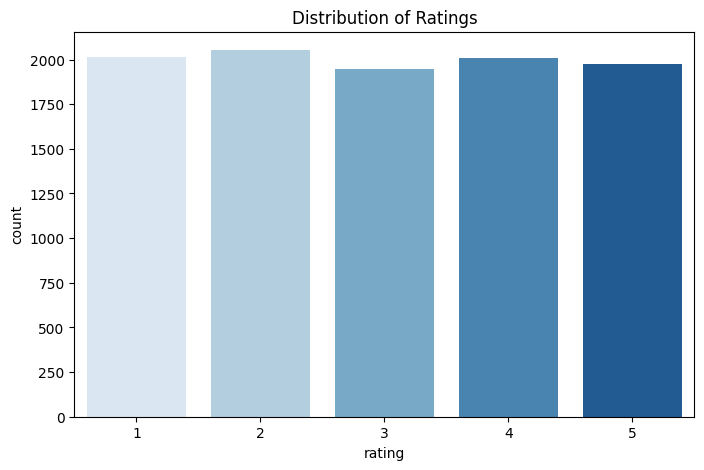

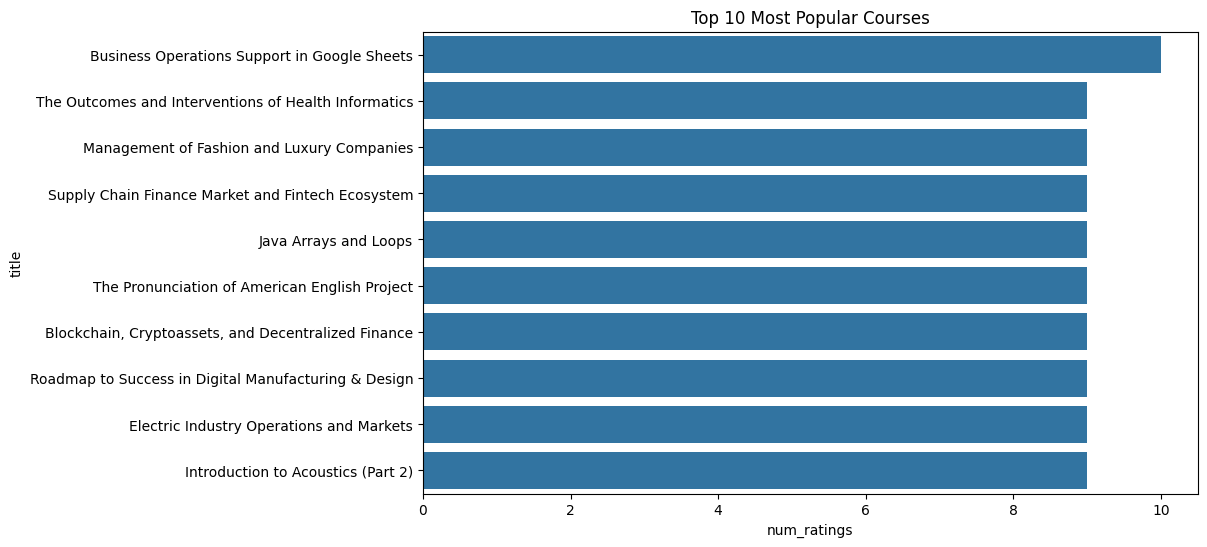


Content Based Recommendations


,course_id,title,University,Course Rating
1213,1214,Capstone: Your Story,Wesleyan University,4.4
1481,1482,Script Writing: Write a Pilot Episode for a TV...,Michigan State University,4.3
1629,1630,Write Your First Novel,Michigan State University,3.5
2186,2187,Presentation skills: Public Speaking Project,National Research Tomsk State University,4.7
3481,3482,Transmedia Writing,Michigan State University,4.1



Collaborative Recommendations


,course_id,title,University,Course Rating
296,297,Cost and Economics in Pricing Strategy,University of Virginia,4.8
580,581,"Element, Class, and ID Selectors in CSS",Coursera Project Network,4.7
2377,2378,Probabilistic Deep Learning with TensorFlow 2,Imperial College London,Not Calibrated
2667,2668,Population Health: Governance,Universiteit Leiden,4.8
3380,3381,Big Data Science with the BD2K-LINCS Data Coor...,Icahn School of Medicine at Mount Sinai,4.6



Hybrid Recommendations


,course_id,title,University,Course Rating
1213,1214,Capstone: Your Story,Wesleyan University,4.4
1481,1482,Script Writing: Write a Pilot Episode for a TV...,Michigan State University,4.3
1629,1630,Write Your First Novel,Michigan State University,3.5
2186,2187,Presentation skills: Public Speaking Project,National Research Tomsk State University,4.7
3481,3482,Transmedia Writing,Michigan State University,4.1


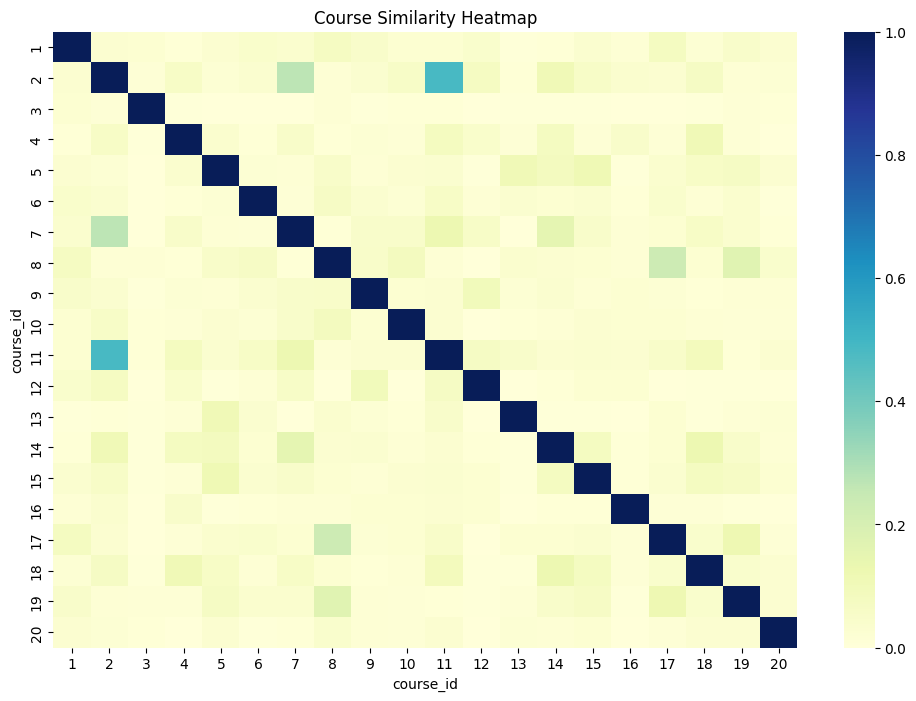


Recommended Courses For User 10


,course_id,title,University,Course Rating
845,846,Building Your Leadership Skills,HEC Paris,4.5
2066,2067,Self Awareness and the Effective Leader,Rice University,4.6
2220,2221,"High Performance Collaboration: Leadership, Te...",Northwestern University,4.8
2348,2349,Foundations of Everyday Leadership,University of Illinois at Urbana-Champaign,4.8
3090,3091,Giving Sense to Your Leadership Experience,HEC Paris,4.5



Pipeline Complete Successfully!


In [5]:
# ============================================================
# AI-Based Personalized Learning Recommendation Engine
# Using Coursera Dataset
# ============================================================

# ============================================================
# STEP 1 — Upload Dataset
# ============================================================

from google.colab import files

uploaded = files.upload()

# ============================================================
# STEP 2 — Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# ============================================================
# STEP 3 — Load Dataset
# ============================================================

courses = pd.read_csv("Coursera.csv")

print("Dataset Shape:", courses.shape)
print("\nColumns:")
print(courses.columns.tolist())

print("\nFirst 5 Rows:")
display(courses.head())

# ============================================================
# STEP 4 — Data Preprocessing
# ============================================================

courses['course_id'] = range(1, len(courses)+1)

courses.rename(
    columns={
        'Course Name':'title'
    },
    inplace=True
)

courses['content'] = (
    courses['Skills'].fillna('') + ' ' +
    courses['Difficulty Level'].fillna('') + ' ' +
    courses['Course Description'].fillna('')
)

courses = courses[
    [
        'course_id',
        'title',
        'University',
        'Difficulty Level',
        'Course Rating',
        'content'
    ]
]

print("\nProcessed Dataset")
display(courses.head())

# ============================================================
# STEP 5 — Create Synthetic User Ratings
# ============================================================

np.random.seed(42)

n_users = 500
n_interactions = 10000

user_ratings = pd.DataFrame({
    'user_id': np.random.randint(
        1,
        n_users + 1,
        n_interactions
    ),
    'course_id': np.random.choice(
        courses['course_id'],
        n_interactions
    ),
    'rating': np.random.randint(
        1,
        6,
        n_interactions
    )
})

print("\nUser Ratings Sample")
display(user_ratings.head())

# ============================================================
# STEP 6 — Exploratory Data Analysis
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=user_ratings,
    x='rating',
    palette='Blues'
)

plt.title('Distribution of Ratings')
plt.show()

# Course popularity

course_popularity = (
    user_ratings
    .groupby('course_id')['rating']
    .count()
    .reset_index()
)

course_popularity.columns = [
    'course_id',
    'num_ratings'
]

course_popularity = course_popularity.merge(
    courses[['course_id','title']],
    on='course_id'
)

top_courses = (
    course_popularity
    .sort_values(
        by='num_ratings',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_courses,
    x='num_ratings',
    y='title'
)

plt.title('Top 10 Most Popular Courses')
plt.show()

# ============================================================
# STEP 7 — Content Based Filtering
# ============================================================

tfidf = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    courses['content']
)

content_similarity = cosine_similarity(
    tfidf_matrix
)

content_sim_df = pd.DataFrame(
    content_similarity,
    index=courses['course_id'],
    columns=courses['course_id']
)

def content_based_recommend(
    course_id,
    top_n=5
):

    similarity_scores = (
        content_sim_df[course_id]
        .drop(course_id)
        .sort_values(
            ascending=False
        )
    )

    recommended_ids = (
        similarity_scores
        .head(top_n)
        .index
        .tolist()
    )

    return courses[
        courses['course_id']
        .isin(recommended_ids)
    ][
        [
            'course_id',
            'title',
            'University',
            'Course Rating'
        ]
    ]

print("\nContent Based Recommendations")

display(
    content_based_recommend(
        course_id=1,
        top_n=5
    )
)

# ============================================================
# STEP 8 — Collaborative Filtering
# ============================================================

user_item_matrix = (
    user_ratings
    .pivot_table(
        index='user_id',
        columns='course_id',
        values='rating'
    )
    .fillna(0)
)

user_similarity = cosine_similarity(
    user_item_matrix
)

user_sim_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

def collaborative_recommend(
    user_id,
    top_n=5
):

    similar_users = (
        user_sim_df[user_id]
        .drop(user_id)
        .sort_values(
            ascending=False
        )
    )

    nearest_user = similar_users.idxmax()

    already_rated = (
        user_item_matrix
        .loc[user_id]
    )

    already_rated = (
        already_rated[
            already_rated > 0
        ]
        .index
        .tolist()
    )

    neighbor_ratings = (
        user_item_matrix
        .loc[nearest_user]
    )

    recommendations = (
        neighbor_ratings[
            ~neighbor_ratings.index.isin(
                already_rated
            )
        ]
    )

    recommendations = (
        recommendations[
            recommendations > 0
        ]
        .sort_values(
            ascending=False
        )
        .head(top_n)
        .index
        .tolist()
    )

    return courses[
        courses['course_id']
        .isin(recommendations)
    ][
        [
            'course_id',
            'title',
            'University',
            'Course Rating'
        ]
    ]

print("\nCollaborative Recommendations")

display(
    collaborative_recommend(
        user_id=1,
        top_n=5
    )
)

# ============================================================
# STEP 9 — Hybrid Recommendation System
# ============================================================

def hybrid_recommend(
    user_id,
    last_course_id,
    top_n=5
):

    content_recs = content_based_recommend(
        last_course_id,
        top_n
    )

    collab_recs = collaborative_recommend(
        user_id,
        top_n
    )

    recommendations = pd.concat(
        [
            content_recs,
            collab_recs
        ]
    )

    recommendations = (
        recommendations
        .drop_duplicates(
            subset='course_id'
        )
        .head(top_n)
    )

    return recommendations

print("\nHybrid Recommendations")

display(
    hybrid_recommend(
        user_id=1,
        last_course_id=1,
        top_n=5
    )
)

# ============================================================
# STEP 10 — Similarity Heatmap
# ============================================================

sample_ids = (
    courses['course_id']
    .head(20)
    .tolist()
)

sample_heatmap = (
    content_sim_df
    .loc[
        sample_ids,
        sample_ids
    ]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    sample_heatmap,
    cmap='YlGnBu'
)

plt.title(
    'Course Similarity Heatmap'
)

plt.show()

# ============================================================
# STEP 11 — Example Recommendation
# ============================================================

print("\nRecommended Courses For User 10")

display(
    hybrid_recommend(
        user_id=10,
        last_course_id=50,
        top_n=5
    )
)

print("\nPipeline Complete Successfully!")